# Fig: Infotaxis vs MAP, number of remaining cells: pmax_th=0.95

Reference: 
- `fig_4_8C_S7_infotaxis_MAP_cmp.ipynb`

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import seaborn as sns

In [2]:
from data_prep_plot.plot_utils import get_beam_search_space_ratio
from data_prep_plot.simulation_data_prep import get_success_fname

In [3]:
# Set path
path_data = Path("/Volumes/ssd_2tb_1/infotaxis_simu_2026")

path_fig = Path("../figs_paper_2026")

In [4]:
path_infotaxis = path_data / "20260530_infotaxis_match_summary_compiled_pmax095_pmaxDiff1e-5"
path_MAP = path_data / "20260530_MAP_match_summary_compiled_pmax095_pmaxDiff1e-5"

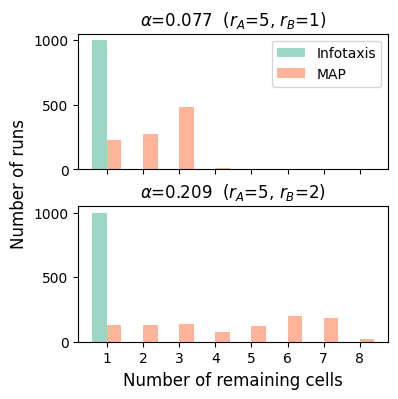

In [5]:
pmax_th = 0.95
pmax_diff_th = 1e-5

cr = 5
br_all = [1, 2]
pm = 0.001


colors = sns.color_palette("Set2")
alpha = 0.65

fig, ax_n = plt.subplots(2, 1, figsize=(4, 4), sharex=True, sharey=True)
fig.subplots_adjust(hspace=0.27)


for br_seq, br in enumerate([1, 2]):

    alpha_grid = get_beam_search_space_ratio(cr, br)

    # Load summary and ph details
    df_infotaxis = pd.read_csv(
        path_infotaxis / get_success_fname(
            search_type="infotaxis", cr=cr, br=br, simulation_type="simple",
            pmax_th=pmax_th, pmax_diff_th=pmax_diff_th,
            pm_agent=pm,
        ), index_col=0
    )
    df_MAP = pd.read_csv(
        path_MAP / get_success_fname(
            search_type="MAP", cr=cr, br=br, simulation_type="simple",
            pmax_th=pmax_th, pmax_diff_th=pmax_diff_th,
            pm_agent=pm,
        ), index_col=0
    )

    bins = np.arange(1, 10)-0.5

    ax_n[br_seq].hist(
        [df_infotaxis["num_grid_left"], df_MAP["num_grid_left"]],
        bins=bins, color=[colors[0], colors[1]], alpha=alpha
    )
    ax_n[br_seq].set_title(
        fr"$\alpha$={alpha_grid:.3f}  ($r_A$={cr}, $r_B$={br})",
        fontsize=12, #fontweight="bold"
    )

ax_n[0].legend(["Infotaxis", "MAP"])
ax_n[0].set_xticks(np.arange(1, 9))
ax_n[1].set_xlabel("Number of remaining cells", fontsize=12)
ax_n[0].set_ylabel("Number of runs                               ", fontsize=12)

plt.show()

fig.savefig(
    path_fig / f"fig_num_remaining_cells_infotaxis_MAP_cmp.png",
    dpi=300, bbox_inches="tight"
)